# MATRIX Testbed — Actuator & Sensor Timing Analysis
This Jupyter notebook dynamically loads, processes, and evaluates `turntable_timing.csv`, `transfer_unit_timing.csv`, and `conveyor_timing.csv` to cleanly reconstruct precise **Digital Timing Diagrams**.

### Features:
* Automatically maps sequential **HIGH/LOW** states into chronological square wave pulses.
* Calculates exact step offsets using incremental captured duration values.
* Generates flat, stacked subplots using **Matplotlib** for deep operational cycle analytics.

Author: Kananelo Chabeli

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_and_process_timing_csv(filepath):
    """
    Reads a timing CSV, reconstructs sequential timeline coordinates (t, state),
    and formats data specifically for digital waveform rendering.
    """
    if not os.path.exists(filepath):
        print(f"⚠️ Warning: File {filepath} not found. Skipping.")
        return {}
    
    try:
        df = pd.read_csv(filepath)
    except Exception as e:
        print(f"❌ Error reading {filepath}: {e}")
        return {}
        
    if df.empty:
        print(f"ℹ️ File {filepath} is empty.")
        return {}

    # Standardise column data types
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Duration_Sec'] = pd.to_numeric(df['Duration_Sec'], errors='coerce').fillna(0.0)
    df['State'] = df['State'].astype(str).str.upper().map({'HIGH': 0, 'LOW': 1}).fillna(0)

    # Sort chronologically to preserve physical signal context transitions
    df = df.sort_values(by='Timestamp').reset_index(drop=True)
    
    tag_waveforms = {}
    grouped = df.groupby('Tag_Name')

    for tag, group in grouped:
        t_coords = [0.0]
        state_coords = []
        
        # Infer baseline logical state (opposite of first recorded transition trigger)
        first_recorded_state = group.iloc[0]['State']
        current_state = 1 if first_recorded_state == 0 else 0
        state_coords.append(current_state)
        
        cumulative_time = 0.0
        for _, row in group.iterrows():
            duration = row['Duration_Sec']
            next_state = row['State']
            
            # Track step progression
            cumulative_time += duration
            t_coords.append(cumulative_time)
            state_coords.append(current_state)  # Hold value until edge transition hit
            
            t_coords.append(cumulative_time)
            state_coords.append(next_state)     # Instant vertical edge flip
            
            current_state = next_state

        tag_waveforms[tag] = (np.array(t_coords), np.array(state_coords))
        
    return tag_waveforms

In [3]:
def plot_digital_timing_diagram(zone_name, waveforms):
    """
    Generates a clean, stacked multi-row digital timing diagram layout.
    """
    if not waveforms:
        print(f"No valid state logic sequences found to plot for Zone: {zone_name}.")
        return

    num_tags = len(waveforms)
    fig, axes = plt.subplots(num_tags, 1, figsize=(12, 2.2 * num_tags), sharex=True)
    
    if num_tags == 1:
        axes = [axes]
        
    fig.suptitle(f"Digital Timing Diagram — {zone_name} Station", fontsize=14, fontweight='bold', y=0.99)
    
    for idx, (tag, (t, states)) in enumerate(waveforms.items()):
        ax = axes[idx]
        
        # Draw clean step traces
        ax.step(t, states, where='post', color='#007acc', linewidth=2.5)
        ax.fill_between(t, states, step="post", color='#007acc', alpha=0.12)
        
        # Format aesthetics
        ax.set_ylabel(tag, rotation=0, ha='right', va='center', fontsize=10, fontweight='bold')
        ax.set_ylim(-0.2, 1.2)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['LOW', 'HIGH'], fontsize=9)
        ax.grid(True, which='both', linestyle='--', alpha=0.4, color='#ccc')
        
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    axes[-1].set_xlabel("Relative Elapsed Operational Cycle Time (Seconds)", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


Processing digital waveforms for Turntable Zone...


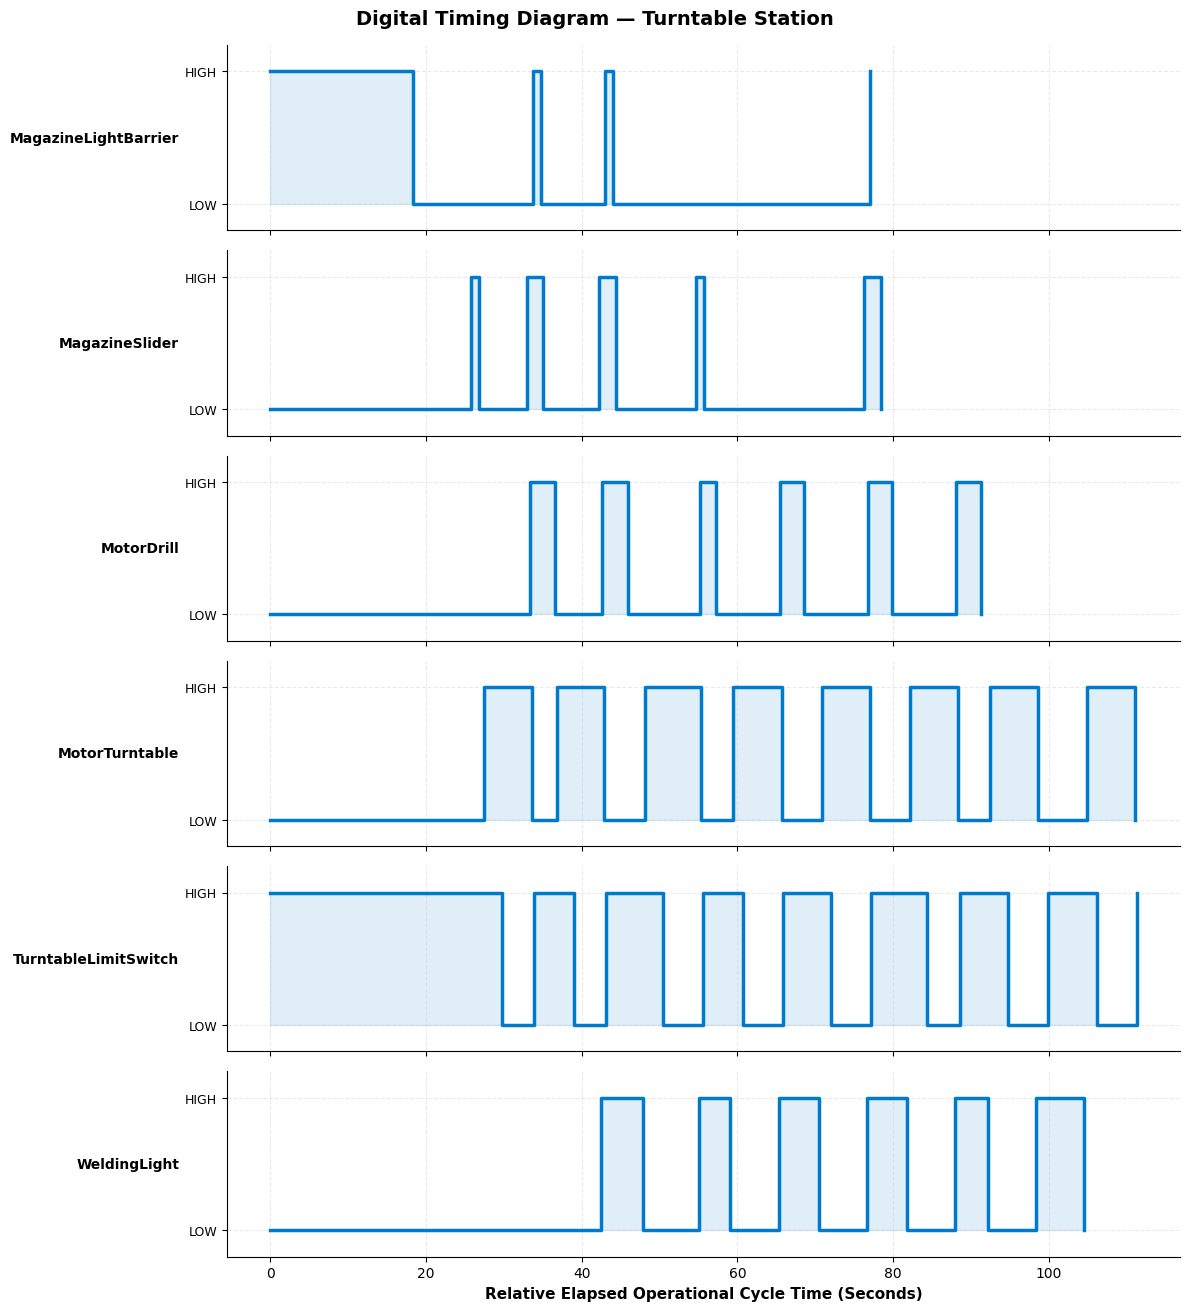


Processing digital waveforms for Transfer Unit Zone...


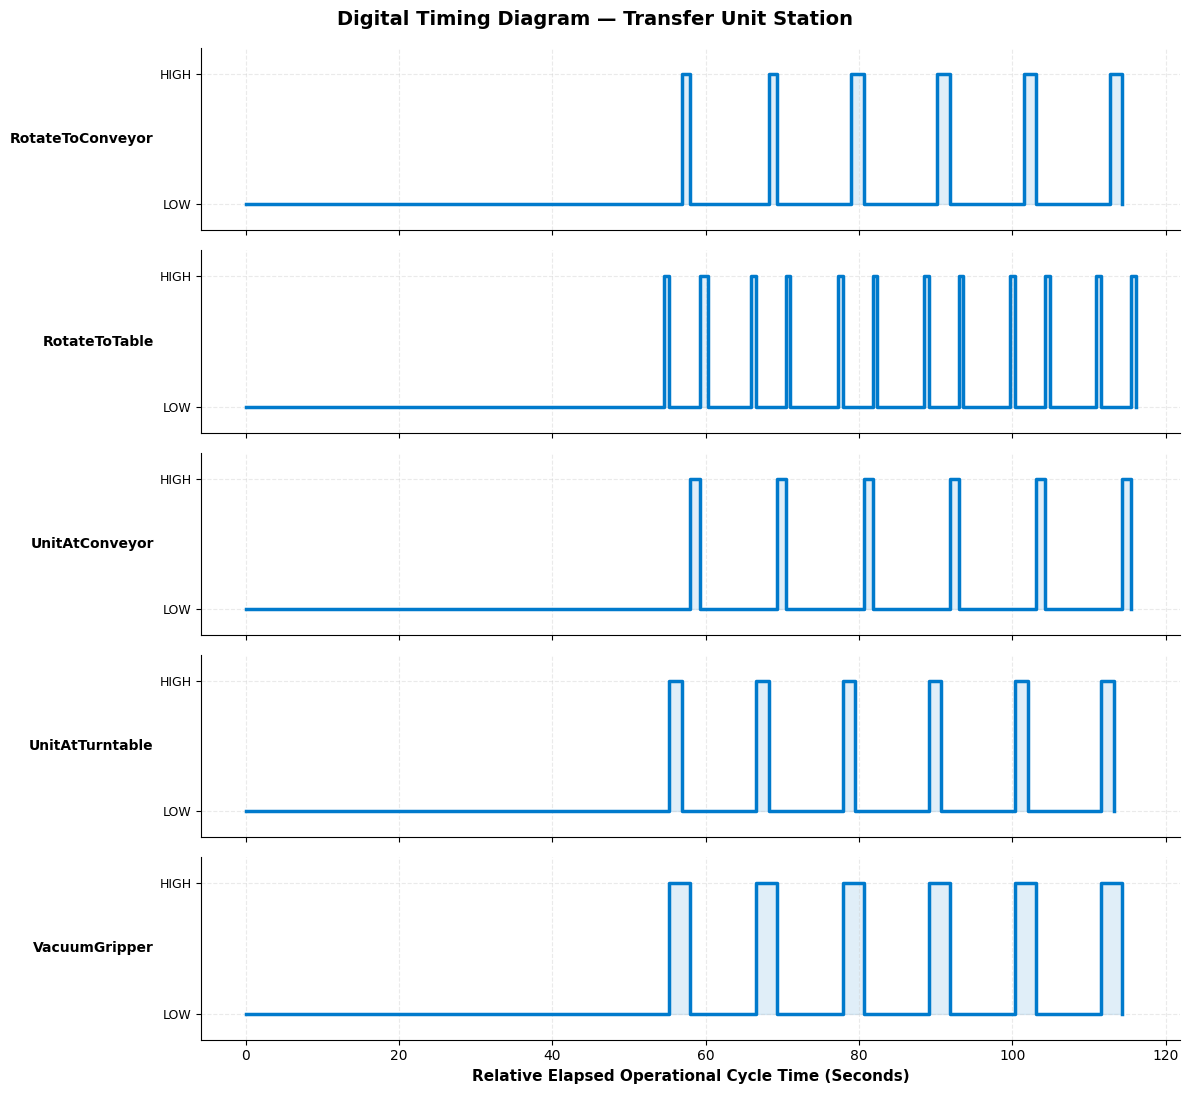


Processing digital waveforms for Conveyor Zone...


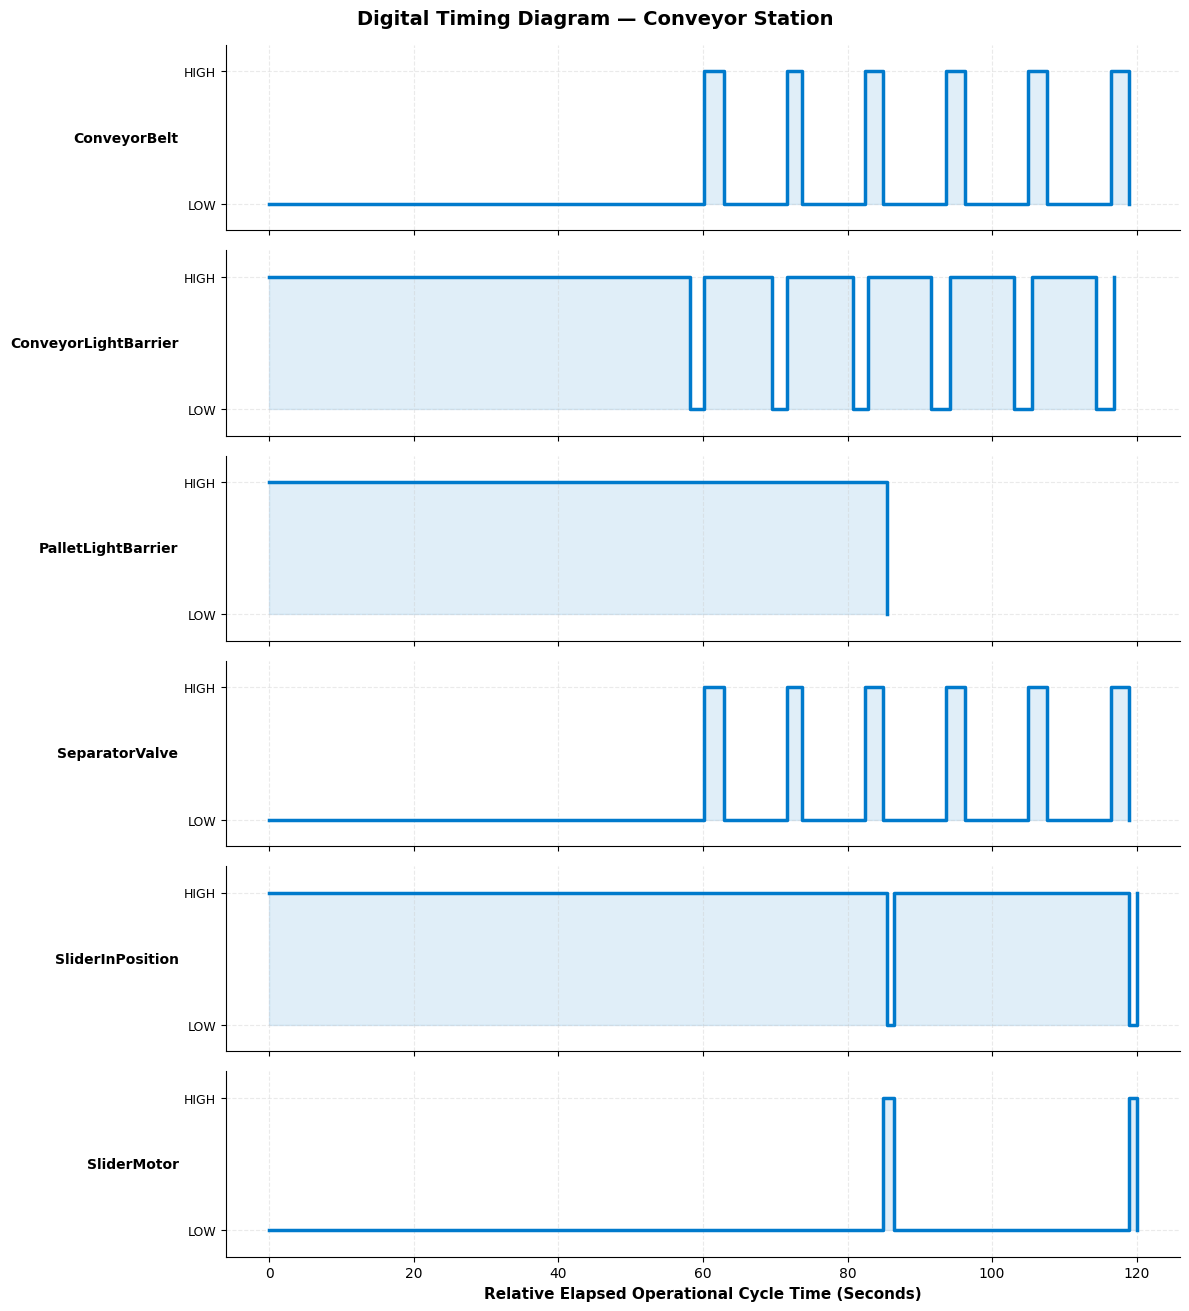

In [5]:
# --- Execution Entry Point ---
files_to_render = {
    "Turntable": "..\\data\\turntable_timing.csv",
    "Transfer Unit": "..\\data\\transfer_unit_timing.csv",
    "Conveyor": "..\\data\\conveyor_timing.csv"
}

for zone, filename in files_to_render.items():
    print(f"\nProcessing digital waveforms for {zone} Zone...")
    zone_data = load_and_process_timing_csv(filename)
    plot_digital_timing_diagram(zone, zone_data)